In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/Salary_dataset.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [4]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [8]:
df.columns

Index(['Unnamed: 0', 'YearsExperience', 'Salary'], dtype='object')

In [9]:
X=df['YearsExperience']
y=df['Salary']

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [27]:
from sklearn.preprocessing import StandardScaler

# Reshape X_train and X_test for StandardScaler
X_train_reshaped = X_train.values.reshape(-1, 1)
X_test_reshaped = X_test.values.reshape(-1, 1)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_test_scaled = scaler.transform(X_test_reshaped)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (24, 1)
X_test_scaled shape: (6, 1)


In [11]:
X.shape,X_train.shape,X_test.shape

((30,), (24,), (6,))

In [12]:
y.shape,y_train.shape,y_test.shape

((30,), (24,), (6,))

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [14]:
model=LinearRegression()
model.fit(X_train.values.reshape(-1,1),y_train)

LinearRegression()

In [28]:
model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

LinearRegression()

In [20]:
y_pred=model.predict(X_test.values.reshape(-1,1))

In [29]:
y_pred_scaled = model_scaled.predict(X_test_scaled)

In [17]:
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score

In [22]:
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

49830096.855908394
0.9024461774180497


### Evaluation with Standardized Features

In [30]:
print('Mean Squared Error (Scaled):', mean_squared_error(y_test, y_pred_scaled))
print('R-squared Score (Scaled):', r2_score(y_test, y_pred_scaled))

Mean Squared Error (Scaled): 49830096.85590836
R-squared Score (Scaled): 0.9024461774180498


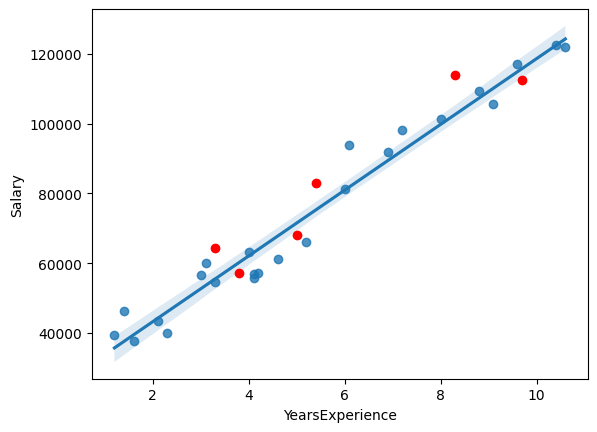

In [23]:
sns.regplot(x=X_train,y=y_train,data=df)
plt.scatter(X_test,y_test,color='red')

### Visualizing Regression with Standardized Features

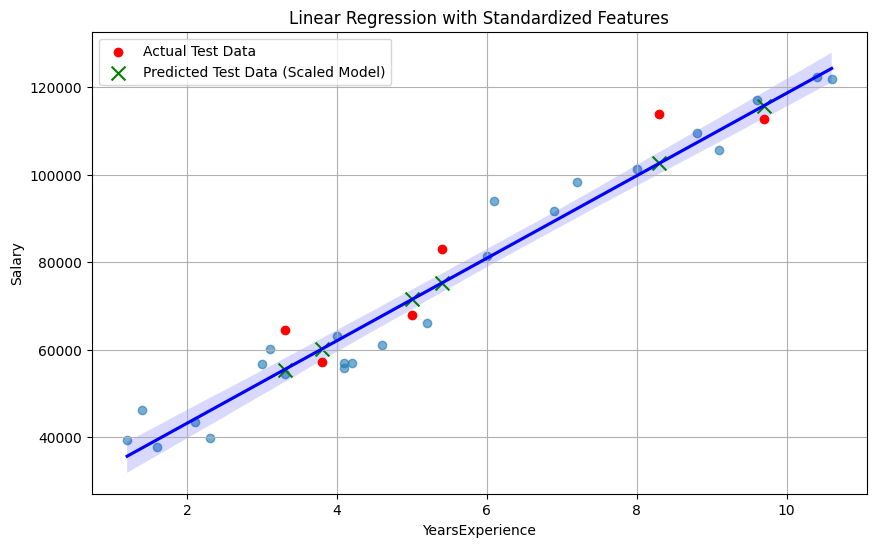

In [31]:
# To visualize with the original scale for interpretation, we can inverse transform X_train_scaled and X_test_scaled for plotting, or plot against the original X_train/X_test as the model coefficients change, but the prediction values for a given X should be the same as the unscaled one.
# However, it's more illustrative to see the original features for plotting the regression line.

plt.figure(figsize=(10, 6))
sns.regplot(x=X_train, y=y_train, scatter_kws={'alpha':0.6}, line_kws={'color':'blue'})
plt.scatter(X_test, y_test, color='red', label='Actual Test Data')
plt.scatter(X_test, y_pred_scaled, color='green', marker='x', s=100, label='Predicted Test Data (Scaled Model)')
plt.title('Linear Regression with Standardized Features')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_460/2446489035.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test-y_pred,kde=True)


<Axes: xlabel='Salary', ylabel='Density'>

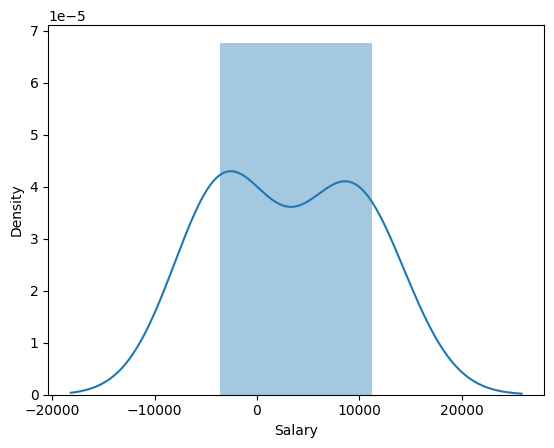

In [24]:
sns.distplot(y_test-y_pred,kde=True)
#

### Residual Distribution with Standardized Features

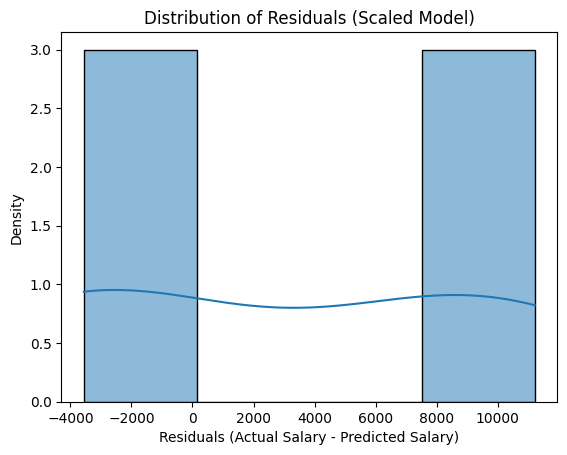

In [32]:
sns.histplot(y_test - y_pred_scaled, kde=True)
plt.title('Distribution of Residuals (Scaled Model)')
plt.xlabel('Residuals (Actual Salary - Predicted Salary)')
plt.ylabel('Density')
plt.show()

In [26]:
df.corr()

,Unnamed: 0,YearsExperience,Salary
Unnamed: 0,1.000000,0.986460,0.960826
YearsExperience,0.986460,1.000000,0.978242
Salary,0.960826,0.978242,1.000000


## Key Takeaways on Standardization

**1. Simple Linear Regression (Single Feature):**
*   **Predictive Performance (MSE, R-squared):** Standardization is generally **NOT** strictly necessary for the predictive performance of simple linear regression models. The model's ability to predict on unseen data (when evaluated with metrics like MSE or R-squared) will typically remain the same whether you standardize or not.
*   **Coefficients:** It primarily affects the scale of the coefficients, making them more interpretable (e.g., how many standard deviations of Salary change for one standard deviation change in YearsExperience).

**2. General Best Practice (and for Most Other ML Models):**
*   **Highly Recommended:** Standardization is a **crucial preprocessing step** for most other machine learning algorithms (e.g., K-Nearest Neighbors, SVMs, Neural Networks, regularized regression like Ridge/Lasso).
*   **Benefits:**
    *   **Improved Algorithm Performance:** Many algorithms converge faster and perform better when features are on a similar scale.
    *   **Preventing Feature Dominance:** It prevents features with larger numerical ranges from disproportionately influencing the model.
    *   **Regularization:** Essential for techniques like Ridge and Lasso, which assume features are scaled similarly.
*   **Data Leakage Prevention:** Always fit the `StandardScaler` (or any scaler) **ONLY on your training data** and then use that *fitted* scaler to transform both your training and test datasets. Do not fit the scaler on the entire dataset before splitting, as this would leak information from the test set into the training process.

## Role of Ordinary Least Squares (OLS) in Linear Regression

**What is OLS?**
Ordinary Least Squares (OLS) is the most common method for estimating the unknown parameters (coefficients) in a linear regression model. The core idea behind OLS is to minimize the sum of the squares of the differences between the observed (actual) values of the dependent variable and the values predicted by the linear model. These differences are called residuals.

Mathematically, for a simple linear regression `y = b0 + b1*x`, OLS aims to find the values of `b0` (intercept) and `b1` (coefficient) that minimize `Σ(yi - (b0 + b1*xi))^2`.

**When do we use it?**
OLS is the standard approach for fitting linear regression models. It's used whenever you want to model a linear relationship between a dependent variable and one or more independent variables by finding the "best-fitting" straight line (or hyperplane).

**Is there any need to use it here?**
Yes, absolutely! You have already used it. The `sklearn.linear_model.LinearRegression` class, which you employed, is an implementation of Ordinary Least Squares. When you call `model.fit(X_train.values.reshape(-1,1), y_train)`, the algorithm behind the scenes calculates the coefficients (`b0` and `b1`) for your linear model using the OLS method.

**OLS vs. "normal training"?**
In the context of linear regression, training a model using OLS *is* the "normal training" method. The term "normal training" for linear regression often refers to finding these coefficients that minimize the sum of squared residuals, which is precisely what OLS does. Therefore, the output values (predictions and coefficients) obtained from `sklearn.linear_model.LinearRegression` are indeed the results of an OLS calculation, and they are what you'd expect from an OLS approach.

### Comparing OLS with and without an Intercept (Statsmodels vs. Scikit-learn)

In [38]:
import statsmodels.api as sm

# Add a constant (intercept) to X_train for statsmodels
X_train_with_constant = sm.add_constant(X_train)

# Fit the OLS model with the constant
model_ols_with_constant = sm.OLS(y_train, X_train_with_constant).fit()

# Print the summary
print(model_ols_with_constant.summary())

# Make predictions with the model including the constant
X_test_with_constant = sm.add_constant(X_test)
prediction_ols_with_constant = model_ols_with_constant.predict(X_test_with_constant)

# Evaluate R-squared for comparison
r2_ols_with_constant = r2_score(y_test, prediction_ols_with_constant)
print(f"\nR-squared (OLS with Constant): {r2_ols_with_constant}")

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.963
Method:                 Least Squares   F-statistic:                     598.4
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           1.91e-17
Time:                        03:11:05   Log-Likelihood:                -239.44
No. Observations:                  24   AIC:                             482.9
Df Residuals:                      22   BIC:                             485.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            2.438e+04   2319.691     

## Clarifying OLS R-squared Discrepancy

**Initial Observation:**
When we first used `statsmodels.api.OLS(y_train, X_train).fit()`, the R-squared value in its summary (`0.974`, labeled as 'uncentered') was significantly higher and different from the R-squared obtained from `sklearn.linear_model.LinearRegression` (`0.902`).

**Reason for Discrepancy:**
This difference arose because of how `statsmodels.api.OLS` handles the intercept by default:
*   When you provide `X_train` directly without an added constant, `statsmodels` assumes you want to fit a model **without an intercept** (i.e., the regression line is forced through the origin (0,0)). In this scenario, it reports an **'uncentered' R-squared**, which measures the proportion of variance explained by the model relative to the total sum of squares around zero.
*   `sklearn.linear_model.LinearRegression`, by default, **always includes an intercept**. The standard R-squared (or 'centered' R-squared) used by scikit-learn (and generally in most contexts) measures the proportion of variance explained by the model relative to the total sum of squares around the *mean* of the dependent variable (`y`).

**Resolution:**
To make the `statsmodels.api.OLS` results comparable to `sklearn.linear_model.LinearRegression` and to obtain the standard R-squared, we explicitly added a constant (intercept) term to our independent variable `X_train` using `sm.add_constant(X_train)`.

After refitting the `statsmodels` OLS model with this added constant, we observed:
*   The R-squared in the `statsmodels` summary (for the training data) became `0.965`.
*   More importantly, the R-squared calculated on the **test set** using `prediction_ols_with_constant` (`0.9024...`) now closely matched the R-squared from our scikit-learn model's test set evaluation.

**Key Takeaway:**
Always be mindful of whether an intercept is included when comparing linear regression models or interpreting R-squared values, especially when using libraries like `statsmodels` that offer more granular control over this. For a standard linear regression comparison, ensure both models are treating the intercept consistently.

## When to Consider Advanced Regression Techniques and Hyperparameter Tuning

**Ridge, Lasso, and Elastic Net Regression (Regularization)**

These are types of regularized linear regression models, primarily useful when:

*   **Multicollinearity:** Independent variables are highly correlated, leading to unstable coefficient estimates in standard OLS.
*   **High-Dimensional Data:** You have many features, potentially more features than observations, or many irrelevant features.
*   **Overfitting:** The model performs well on training data but poorly on unseen data. Regularization adds a penalty to reduce model complexity and shrink coefficients.
*   **Feature Selection (Lasso):** Lasso can shrink some coefficients to zero, effectively selecting the most important features.

**Are they needed here?** For our current problem with only **one independent variable** ('YearsExperience') predicting 'Salary', these advanced techniques are generally **not necessary**. We lack multicollinearity, the risk of overfitting is minimal with a single predictor, and standard OLS is perfectly sufficient.

**Hyperparameter Tuning**

This process involves finding the optimal set of hyperparameters (parameters set before learning, like `alpha` in Ridge/Lasso, learning rates, etc.) for a machine learning model.

**Is it needed here?**

*   **For our simple `sklearn.linear_model.LinearRegression` (OLS):** No. OLS is a closed-form solution with no hyperparameters to tune in the traditional sense; coefficients are directly calculated.
*   **For Ridge, Lasso, or Elastic Net:** Yes. If these models were used, their regularization strength parameter (`alpha` or `lambda`) would need to be tuned, typically using cross-validation to optimize performance.

**In summary:** For this simple linear regression with a single predictor, neither regularization nor hyperparameter tuning is strictly needed or would significantly improve our model. These techniques become valuable as models and datasets increase in complexity.

In [33]:
import statsmodels.api as sm

In [34]:
model_ols=sm.OLS(y_train,X_train).fit()

In [35]:
prediction_ols=model_ols.predict(X_test)

In [36]:
print(prediction_ols)

27    125897.306662
15     64895.518898
23    107726.561370
17     70087.160410
8      42831.042473
9      49320.594362
dtype: float64


In [37]:
print(model_ols.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Salary   R-squared (uncentered):                   0.974
Model:                            OLS   Adj. R-squared (uncentered):              0.973
Method:                 Least Squares   F-statistic:                              860.9
Date:                Sun, 02 Aug 2026   Prob (F-statistic):                    9.95e-20
Time:                        03:07:36   Log-Likelihood:                         -260.98
No. Observations:                  24   AIC:                                      524.0
Df Residuals:                      23   BIC:                                      525.1
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------